# RQ1: Constructor Dynasties

**Question.** Which F1 constructors have dominated the sport across different eras, and how has competitive balance shifted over 75 years?

This notebook is the prototyping ground for Chapter 1 of the ship product at https://f1-info-viz.vercel.app/. We work through the raw dominance patterns from 1950 to 2025 using yearly points and wins per constructor, and we sketch the two charts that eventually land in the app: a stacked-area dynasty timeline with era annotations, and a lollipop "Dominance Index" that measures the top team's share of wins in each season.

**Approach.** Aggregate race wins and championship points by team and season. Bucket years into nine eras that match regulation or organizational shifts (The Founders 1950-1957, British Invasion 1958-1965, Cosworth Age 1966-1979, Turbo Wars 1980-1989, Williams Dynasty 1990-1999, Schumacher Era 2000-2008, Red Bull Reign 2009-2013, Silver Domination 2014-2021, Verstappen Era 2022-2025). For each season, compute a Dominance Index as `top constructor's wins / total races that year`, expressed as a percentage. No HHI, no entropy measures, nothing abstract. Just the share of wins, which any F1 fan can read straight off the chart.

**Dataset.** `rq1_constructor_dominance.csv`, yearly rows of Points, Wins, Podiums per constructor.

**EDA notebook:** see `data_EDA.ipynb`. External EDA link: TBD.

In [1]:
import plotly.io as pio
pio.renderers.default = 'png'
pio.kaleido.scope.default_width = 900
pio.kaleido.scope.default_height = 520
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

pd.set_option('display.max_rows', 100)

df = pd.read_csv('../final_datasets/rq1_constructor_dominance.csv')
print(f"Shape: {df.shape}")
print(f"\nColumn types:\n{df.dtypes}")
print(f"\nFirst 5 rows:")
df.head()

/var/folders/9r/jpz6t9fx7jv6tyyxhcmg5k200000gn/T/ipykernel_92120/2206896942.py:3: DeprecationWarning: 
Use of plotly.io.kaleido.scope.default_width is deprecated and support will be removed after September 2025.
Please use plotly.io.defaults.default_width instead.

  pio.kaleido.scope.default_width = 900
/var/folders/9r/jpz6t9fx7jv6tyyxhcmg5k200000gn/T/ipykernel_92120/2206896942.py:4: DeprecationWarning: 
Use of plotly.io.kaleido.scope.default_height is deprecated and support will be removed after September 2025.
Please use plotly.io.defaults.default_height instead.

  pio.kaleido.scope.default_height = 520


Shape: (1126, 5)

Column types:
Year             int64
Constructor        str
Points         float64
Win              int64
Podium           int64
dtype: object

First 5 rows:


,Year,Constructor,Points,Win,Podium
0,1950,Alfa Romeo,92.0,6,13
1,1950,Talbot-Lago,20.0,0,2
2,1950,Ferrari,18.0,0,3
3,1950,Kurtis Kraft,14.0,1,1
4,1950,Maserati,11.0,0,1


## 1. Data Quality Check

In [2]:
# Missing values
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")
print(f"\nYear range: {df['Year'].min()} – {df['Year'].max()}")
print(f"Total unique constructors: {df['Constructor'].nunique()}")
print(f"Total rows: {len(df)}")

Missing values per column:
Year           0
Constructor    0
Points         0
Win            0
Podium         0
dtype: int64

Duplicate rows: 0

Year range: 1950 – 2026
Total unique constructors: 209
Total rows: 1126


## 2. Descriptive Statistics

In [3]:
print("Descriptive statistics for numeric columns:\n")
df[['Points', 'Win', 'Podium']].describe().round(2)

Descriptive statistics for numeric columns:



,Points,Win,Podium
count,1126.00,1126.00,1126.00
mean,49.48,1.02,3.08
std,110.63,2.57,5.76
min,0.00,0.00,0.00
25%,0.00,0.00,0.00
50%,8.00,0.00,0.00
75%,48.75,0.00,3.00
max,790.00,21.00,34.00


## 3. Constructors per season

Grid size over 75 years. The 1950s spike is mostly Indianapolis 500 privateers counted in the championship, not a genuine F1 boom. From the mid-1990s onward the grid settles into a steady 10-team shape that has not changed much since.

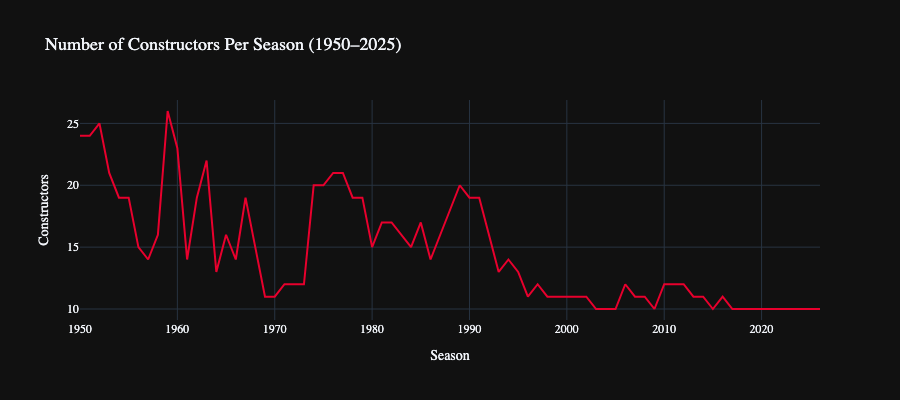

In [4]:
constructors_per_year = df.groupby('Year')['Constructor'].nunique().reset_index(name='Count')

fig = px.line(
    constructors_per_year, x='Year', y='Count',
    title='Number of Constructors Per Season (1950–2025)',
    labels={'Count': 'Constructors', 'Year': 'Season'},
    template='plotly_dark'
)
fig.update_traces(line=dict(color='#e8002d', width=2))
fig.update_layout(
    font=dict(family='DM Sans'),
    title_font_size=18,
    height=400
)
fig.show()

## 4. All-time wins leaderboard

Who has shown up at the front most often across 75 years. Ferrari's lead here is not a modern artifact. They are the only constructor that appears in every single season from 1950 to today. McLaren and Williams build their totals in distinct clusters (McLaren late 80s with Senna and Prost, Williams through the 90s with Mansell, Prost, Hill and Villeneuve). Mercedes and Red Bull are almost entirely modern-era additions, both still accumulating.

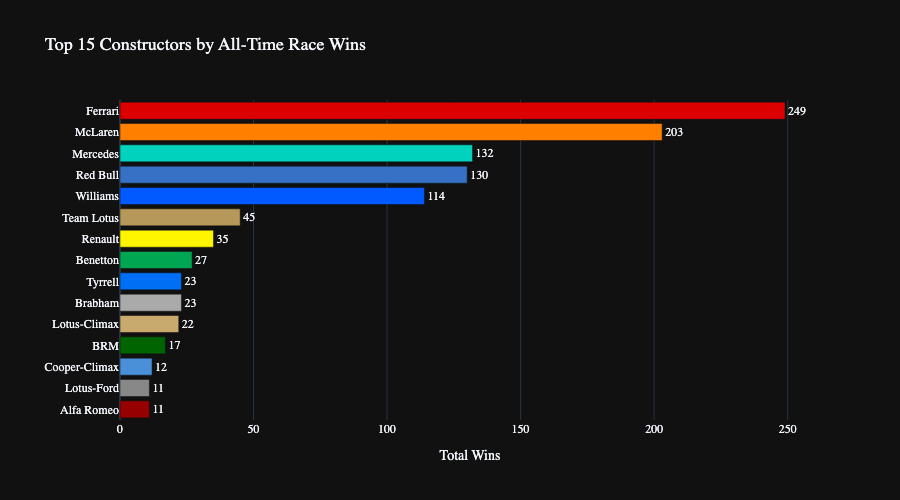

In [5]:
top_wins = df.groupby('Constructor')['Win'].sum().nlargest(15).reset_index()
top_wins = top_wins.sort_values('Win')

# Constructor brand colors
TEAM_COLORS = {
    'Ferrari': '#dc0000', 'McLaren': '#ff8000', 'Mercedes': '#00d2be',
    'Red Bull': '#3671c6', 'Williams': '#005aff', 'Renault': '#fff500',
    'Benetton': '#00a651', 'Team Lotus': '#b5985a', 'Lotus-Climax': '#c8a96e',
    'Brabham': '#aaaaaa', 'Tyrrell': '#006ef5', 'BRM': '#006400',
    'Cooper-Climax': '#4a90d9', 'Alfa Romeo': '#960000', 'Brawn': '#f5f5f5',
    'Vanwall': '#005f3c', 'Maserati': '#c0392b', 'Matra-Ford': '#002395',
    'Alpine': '#0090ff', 'Lotus F1': '#e5c158',
}
colors = [TEAM_COLORS.get(c, '#888888') for c in top_wins['Constructor']]

fig = go.Figure(go.Bar(
    x=top_wins['Win'], y=top_wins['Constructor'],
    orientation='h',
    marker_color=colors,
    text=top_wins['Win'], textposition='outside'
))
fig.update_layout(
    title='Top 15 Constructors by All-Time Race Wins',
    xaxis_title='Total Wins', yaxis_title='',
    template='plotly_dark', height=500,
    font=dict(family='DM Sans'), title_font_size=18,
    margin=dict(l=120)
)
fig.show()

## 5. All-time points leaderboard

Points tell a different story than wins, because the scoring system has changed multiple times: 8 points for a win in the 1950s, 10 from 1991, 25 from 2010, plus fastest-lap and sprint bonuses layered on top. Modern teams accumulate points much faster than historical ones, so this chart visibly tilts toward Mercedes, Red Bull and recent Ferrari. Wins are the cleaner cross-era metric, which is why the ship product uses them for the Dominance Index.

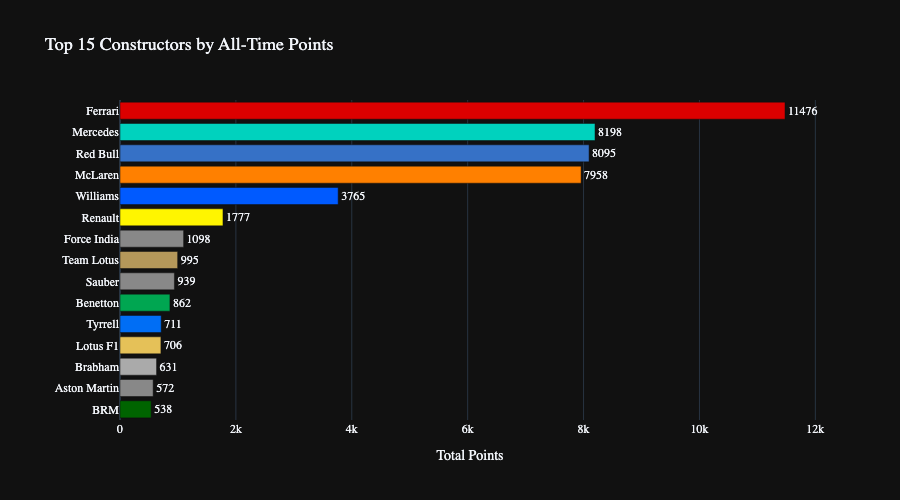

In [6]:
top_pts = df.groupby('Constructor')['Points'].sum().nlargest(15).reset_index()
top_pts = top_pts.sort_values('Points')
colors_pts = [TEAM_COLORS.get(c, '#888888') for c in top_pts['Constructor']]

fig = go.Figure(go.Bar(
    x=top_pts['Points'], y=top_pts['Constructor'],
    orientation='h',
    marker_color=colors_pts,
    text=top_pts['Points'].round(0).astype(int), textposition='outside'
))
fig.update_layout(
    title='Top 15 Constructors by All-Time Points',
    xaxis_title='Total Points', yaxis_title='',
    template='plotly_dark', height=500,
    font=dict(family='DM Sans'), title_font_size=18,
    margin=dict(l=120)
)
fig.show()

## 6. Points distribution

Most constructor-seasons end with very few points. Only a handful of teams score meaningfully each year; the rest fill out the grid. The long right tail (seasons above 400 points) is almost entirely a 2010s-onward phenomenon driven by scoring inflation plus Mercedes and Red Bull monopolizing podiums.

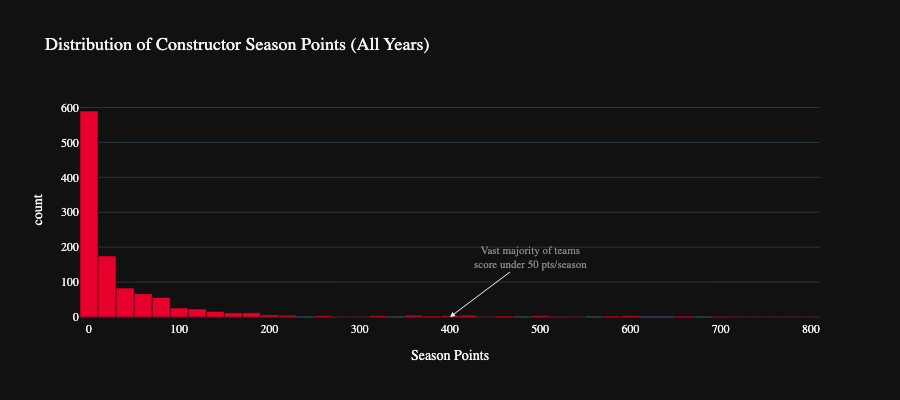

In [7]:
fig = px.histogram(
    df, x='Points', nbins=60,
    title='Distribution of Constructor Season Points (All Years)',
    labels={'Points': 'Season Points', 'count': 'Frequency'},
    template='plotly_dark'
)
fig.update_traces(marker_color='#e8002d', marker_line_color='#0a0a0a', marker_line_width=0.5)
fig.update_layout(
    font=dict(family='DM Sans'), title_font_size=18, height=400,
    annotations=[dict(
        x=400, y=0, xref='x', yref='y',
        text='Vast majority of teams<br>score under 50 pts/season',
        showarrow=True, arrowhead=2, ax=80, ay=-60,
        font=dict(size=11, color='#888888')
    )]
)
fig.show()

---

## Visualization prototyping

From here on the charts iterate toward the stacked area that ships in the app. Each chart is a deliberate step: raw lines, then stacked, then stacked with eras, then the companion Dominance Index.

## 7. Yearly points for the top 6 constructors

Raw signal before stacking. Each line is one team's season points. The big shapes are already visible: Williams spiking through the 90s, Ferrari climbing through the Schumacher run, Mercedes owning 2014-2021, Red Bull with two peaks (2010-2013 with Vettel, 2022-2025 with Verstappen). Alpine and Lotus F1 are rolled into Renault because they are the same constructor lineage re-badged across ownership changes.

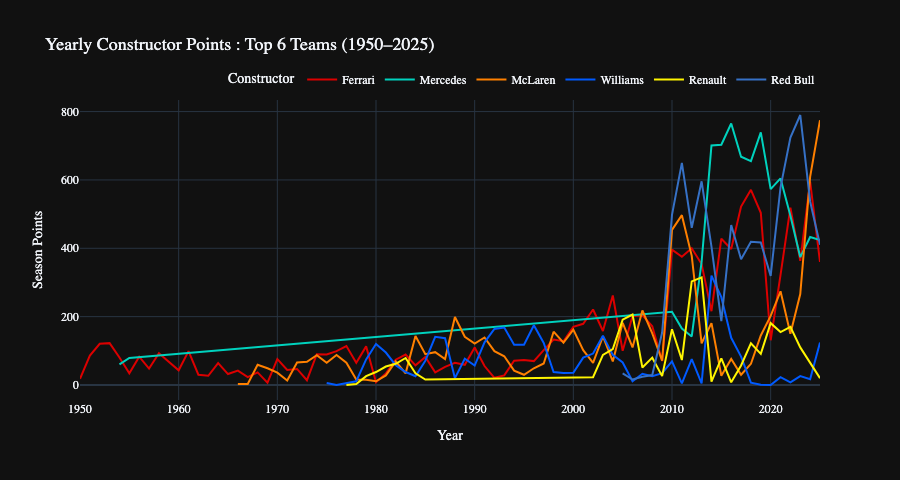

In [8]:
TOP_6 = ['Ferrari', 'McLaren', 'Mercedes', 'Red Bull', 'Williams', 'Renault']
TOP_6_COLORS = {'Ferrari': '#dc0000', 'McLaren': '#ff8000', 'Mercedes': '#00d2be',
                'Red Bull': '#3671c6', 'Williams': '#005aff', 'Renault': '#fff500'}

# Merge Alpine and Lotus F1 into Renault (same lineage)
df_mapped = df.copy()
df_mapped['Constructor'] = df_mapped['Constructor'].replace({'Alpine': 'Renault', 'Lotus F1': 'Renault'})

top6_df = df_mapped[df_mapped['Constructor'].isin(TOP_6) & (df_mapped['Year'] <= 2025)]
top6_yearly = top6_df.groupby(['Year', 'Constructor'])['Points'].sum().reset_index()

fig = px.line(
    top6_yearly, x='Year', y='Points', color='Constructor',
    color_discrete_map=TOP_6_COLORS,
    title='Yearly Constructor Points : Top 6 Teams (1950–2025)',
    labels={'Points': 'Season Points'},
    template='plotly_dark'
)
fig.update_layout(
    font=dict(family='DM Sans'), title_font_size=18, height=480,
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1)
)
fig.show()

## 8. Stacked area, constructor points over time

The core chart. Stacking converts "who scored what" into a visual share of the era, which is how fans actually remember seasons. Colored livery bands replace legend-hunting: Ferrari red, McLaren papaya, Mercedes teal, Red Bull blue, Williams deep blue, Renault yellow. Dynasty shapes emerge as wide bands that eventually thin out. Williams in the 90s gives way to Ferrari through the 2000s, which gives way to Mercedes in the 2010s, which gives way to Red Bull in the 2020s.

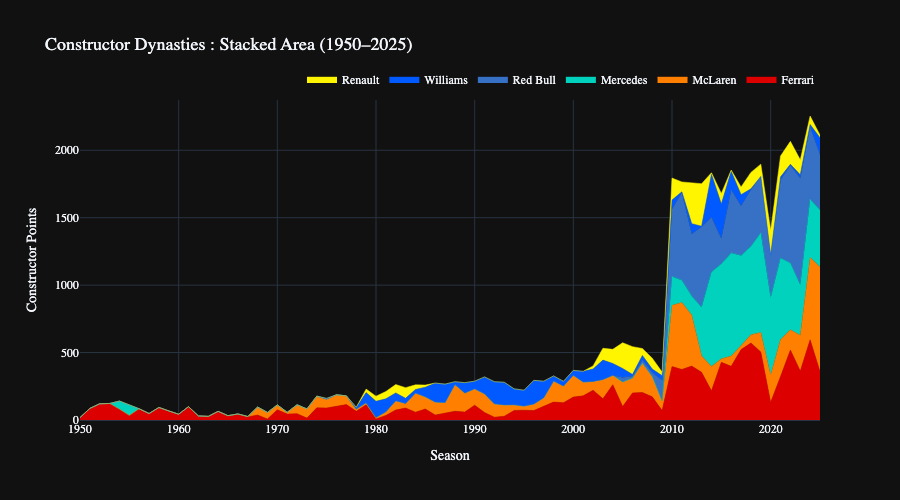

In [9]:
# Pivot: rows=Year, columns=Constructor, values=Points
pivot = top6_yearly.pivot(index='Year', columns='Constructor', values='Points').fillna(0)
pivot = pivot.reindex(columns=TOP_6)  # consistent order

fig = go.Figure()
for team in TOP_6:
    fig.add_trace(go.Scatter(
        x=pivot.index, y=pivot[team],
        mode='lines', name=team,
        stackgroup='one',
        line=dict(width=0.5, color=TOP_6_COLORS[team]),
        fillcolor=TOP_6_COLORS[team],
    ))

fig.update_layout(
    title='Constructor Dynasties : Stacked Area (1950–2025)',
    xaxis_title='Season', yaxis_title='Constructor Points',
    template='plotly_dark', height=500,
    font=dict(family='DM Sans'), title_font_size=18,
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1),
    hovermode='x unified'
)
fig.show()

## 9. Stacked area with era annotations

Adding vertical era bands makes the structural story legible at a glance. Each era is bookended by a regulation or organizational shift:

- **The Founders (1950-1957).** Alfa Romeo wins the first two titles with Nino Farina and Juan Manuel Fangio. Maserati, Mercedes, Ferrari and Vanwall trade wins on a mixed grid of manufacturers and privateers.
- **British Invasion (1958-1965).** Cooper, BRM, Lotus and Brabham pivot the sport to rear-engined, lightweight design. Jim Clark and Graham Hill define the period.
- **Cosworth Age (1966-1979).** The Ford-Cosworth DFV is in almost every non-Ferrari car, and the championship rotates between British constructors and Ferrari.
- **Turbo Wars (1980-1989).** Williams, McLaren and Ferrari push 1,000-plus bhp turbo engines. Closes with the McLaren MP4/4 of 1988: 15 wins from 16 races with Senna and Prost fighting each other.
- **Williams Dynasty (1990-1999).** Active suspension and traction control era, dominated by Williams-Renault. Mansell, Prost, Hill and Villeneuve all win titles in a Williams.
- **Schumacher Era (2000-2008).** Ferrari wins six constructors' titles in a row, built around Michael Schumacher, Jean Todt, Ross Brawn and Rory Byrne. Kimi Raikkonen closes the era with one more in 2007.
- **Red Bull Reign (2009-2013).** Sebastian Vettel wins four consecutive drivers' titles; Brawn GP's 2009 one-off is a footnote inside this era.
- **Silver Domination (2014-2021).** V6 hybrid regulations reward Mercedes' engine programme. Hamilton wins six of eight drivers' titles; Mercedes wins every constructors' title in the era.
- **Verstappen Era (2022-2025).** Ground-effect rules and Red Bull's RB19 produce one of the most dominant single seasons on record in 2023.

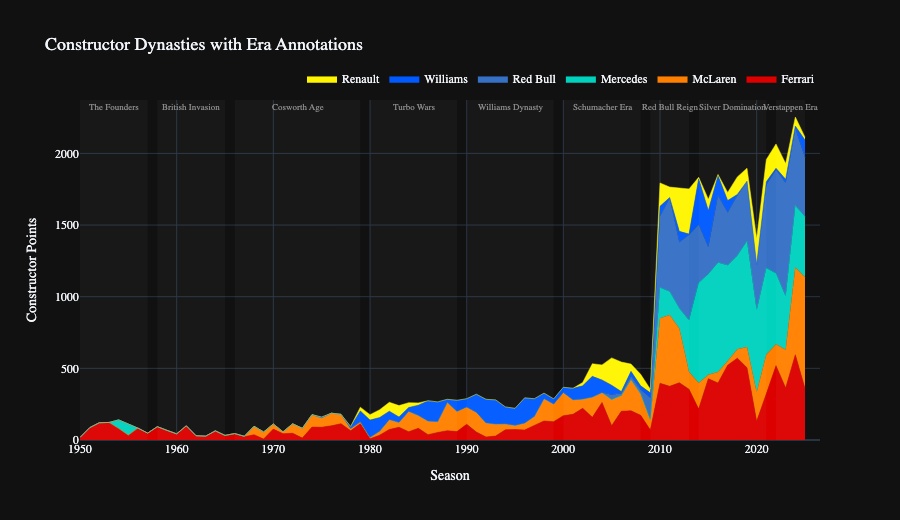

In [10]:
# F1 eras (matching the ship app theme.js)
ERAS = [
    {'start': 1950, 'end': 1957, 'label': 'The Founders'},
    {'start': 1958, 'end': 1965, 'label': 'British Invasion'},
    {'start': 1966, 'end': 1979, 'label': 'Cosworth Age'},
    {'start': 1980, 'end': 1989, 'label': 'Turbo Wars'},
    {'start': 1990, 'end': 1999, 'label': 'Williams Dynasty'},
    {'start': 2000, 'end': 2008, 'label': 'Schumacher Era'},
    {'start': 2009, 'end': 2013, 'label': 'Red Bull Reign'},
    {'start': 2014, 'end': 2021, 'label': 'Silver Domination'},
    {'start': 2022, 'end': 2025, 'label': 'Verstappen Era'},
]

fig = go.Figure()

# Era background bands
for era in ERAS:
    fig.add_vrect(
        x0=era['start'], x1=era['end'],
        fillcolor='rgba(255,255,255,0.03)', line_width=0,
        annotation_text=era['label'],
        annotation_position='top',
        annotation=dict(font_size=9, font_color='#888888')
    )

# Stacked areas
for team in TOP_6:
    fig.add_trace(go.Scatter(
        x=pivot.index, y=pivot[team],
        mode='lines', name=team,
        stackgroup='one',
        line=dict(width=0.5, color=TOP_6_COLORS[team]),
        fillcolor=TOP_6_COLORS[team],
    ))

fig.update_layout(
    title='Constructor Dynasties with Era Annotations',
    xaxis_title='Season', yaxis_title='Constructor Points',
    template='plotly_dark', height=520,
    font=dict(family='DM Sans'), title_font_size=18,
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1),
    hovermode='x unified'
)
fig.show()

## 10. Dominance Index, top team's win share per season

For each season, compute `top constructor's wins / total races that year`, expressed as a percentage. A 90%+ bar means one team won almost every race; a 20-30% bar means the grid was wide open. Red bars flag dominance above 60%, teal bars flag competitive seasons below 40%. The dashed 50% line is the useful reference: anything above it means the top team won more races than everyone else put together.

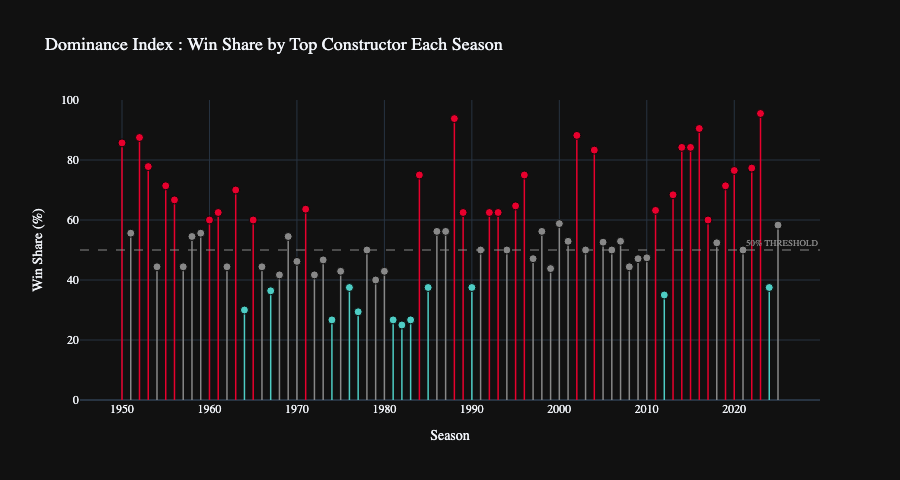

In [11]:
# Calculate dominance % per year
yearly_wins = df[df['Year'] <= 2025].groupby('Year').agg(
    total_wins=('Win', 'sum'),
    max_wins=('Win', 'max')
).reset_index()

# Find which team had the max wins each year
top_team_per_year = df[df['Year'] <= 2025].loc[
    df[df['Year'] <= 2025].groupby('Year')['Win'].idxmax()
][['Year', 'Constructor']].rename(columns={'Constructor': 'TopTeam'})

dominance = yearly_wins.merge(top_team_per_year, on='Year')
dominance['pct'] = (dominance['max_wins'] / dominance['total_wins'] * 100).round(1)
dominance = dominance[dominance['total_wins'] > 0]

# Color gradient: green (competitive) → gray → red (dominant)
def dom_color(pct):
    if pct >= 60:
        return '#e8002d'
    elif pct >= 40:
        return '#888888'
    else:
        return '#4ecdc4'

dominance['color'] = dominance['pct'].apply(dom_color)

fig = go.Figure()

# Stems
for _, row in dominance.iterrows():
    fig.add_trace(go.Scatter(
        x=[row['Year'], row['Year']], y=[0, row['pct']],
        mode='lines', line=dict(color=row['color'], width=1.5),
        showlegend=False, hoverinfo='skip'
    ))

# Dots
fig.add_trace(go.Scatter(
    x=dominance['Year'], y=dominance['pct'],
    mode='markers',
    marker=dict(size=8, color=dominance['color'], line=dict(color='#0a0a0a', width=1)),
    text=dominance.apply(lambda r: f"{r['Year']}: {r['TopTeam']} : {r['pct']}%", axis=1),
    hoverinfo='text',
    name='Dominance %'
))

# 50% threshold line
fig.add_hline(y=50, line_dash='dash', line_color='#888888', line_width=1,
              annotation_text='50% THRESHOLD', annotation_position='top right',
              annotation_font=dict(size=9, color='#888888'))

fig.update_layout(
    title='Dominance Index : Win Share by Top Constructor Each Season',
    xaxis_title='Season', yaxis_title='Win Share (%)',
    yaxis=dict(range=[0, 100]),
    template='plotly_dark', height=480,
    font=dict(family='DM Sans'), title_font_size=18,
    showlegend=False
)
fig.show()

## 11. Dominance extremes

The 15 most dominant seasons next to the 15 most competitive. The dominant panel clusters around familiar names: 2023 Red Bull (95.5%, 21 wins from 22 races, 19 of those by Verstappen personally), 1988 McLaren (93.8%, Senna and Prost sharing 15 from 16), 2002 and 2004 Ferrari with Schumacher, 2014-2016 and 2019-2020 Mercedes with Hamilton. The competitive panel skews earlier, especially the early 80s and late 70s, when six or seven different teams could win races in a single season.

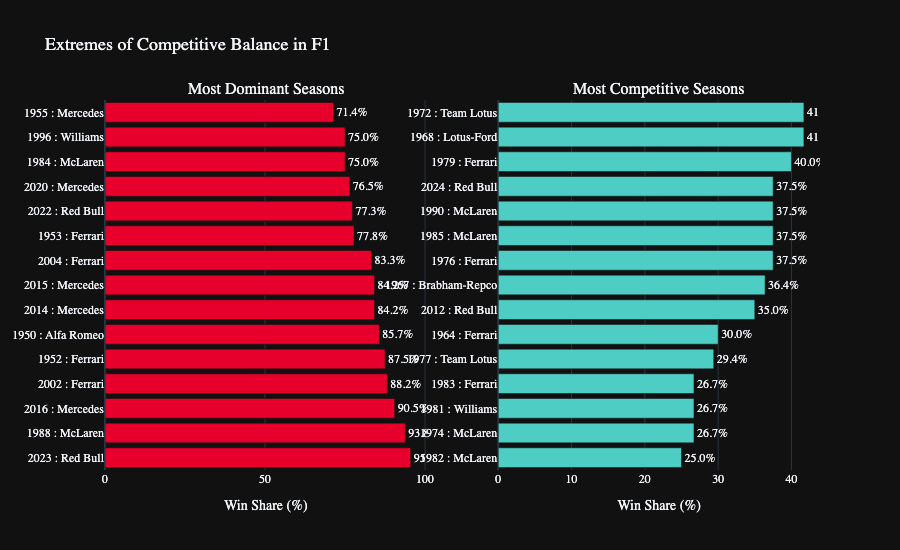

In [12]:
most_dominant = dominance.nlargest(15, 'pct')
most_competitive = dominance.nsmallest(15, 'pct')

fig = make_subplots(rows=1, cols=2, subplot_titles=('Most Dominant Seasons', 'Most Competitive Seasons'))

# Dominant
fig.add_trace(go.Bar(
    y=most_dominant['Year'].astype(str) + ' : ' + most_dominant['TopTeam'],
    x=most_dominant['pct'],
    orientation='h',
    marker_color='#e8002d',
    text=most_dominant['pct'].astype(str) + '%',
    textposition='outside',
    name='Dominant'
), row=1, col=1)

# Competitive
fig.add_trace(go.Bar(
    y=most_competitive['Year'].astype(str) + ' : ' + most_competitive['TopTeam'],
    x=most_competitive['pct'],
    orientation='h',
    marker_color='#4ecdc4',
    text=most_competitive['pct'].astype(str) + '%',
    textposition='outside',
    name='Competitive'
), row=1, col=2)

fig.update_layout(
    title='Extremes of Competitive Balance in F1',
    template='plotly_dark', height=550,
    font=dict(family='DM Sans'), title_font_size=18,
    showlegend=False
)
fig.update_xaxes(title_text='Win Share (%)', row=1, col=1)
fig.update_xaxes(title_text='Win Share (%)', row=1, col=2)
fig.show()

## 12. Decade heatmap

Wins grouped into decades for the top 10 constructors. Dark red cells are dynastic decades: McLaren in the 80s, Williams in the 90s, Ferrari in the 2000s, Mercedes in the 2010s. Emptier columns (the 60s) reflect both smaller grids and more even distribution. This is the compressed version of the stacked-area story.

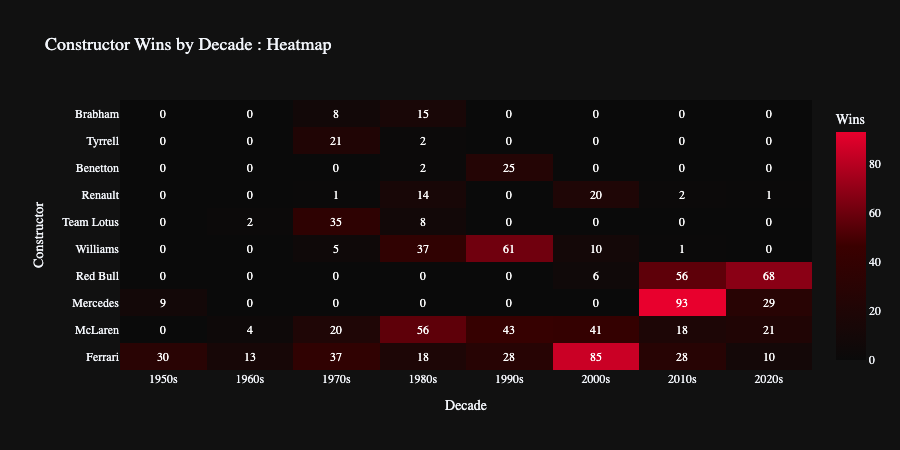

In [13]:
# Create decade column
df_heat = df_mapped[df_mapped['Year'] <= 2025].copy()
df_heat['Decade'] = (df_heat['Year'] // 10 * 10).astype(str) + 's'

# Top 10 constructors by total wins
top10 = df_heat.groupby('Constructor')['Win'].sum().nlargest(10).index.tolist()

heat_data = df_heat[df_heat['Constructor'].isin(top10)].groupby(
    ['Constructor', 'Decade']
)['Win'].sum().reset_index()

heat_pivot = heat_data.pivot(index='Constructor', columns='Decade', values='Win').fillna(0)
# Order constructors by total wins
heat_pivot = heat_pivot.loc[heat_pivot.sum(axis=1).sort_values(ascending=True).index]

fig = px.imshow(
    heat_pivot.values,
    labels=dict(x='Decade', y='Constructor', color='Wins'),
    x=heat_pivot.columns.tolist(),
    y=heat_pivot.index.tolist(),
    color_continuous_scale=['#0a0a0a', '#3a0000', '#e8002d'],
    title='Constructor Wins by Decade : Heatmap',
    template='plotly_dark',
    aspect='auto'
)
fig.update_layout(
    font=dict(family='DM Sans'), title_font_size=18, height=450,
    margin=dict(l=120)
)
fig.update_traces(text=heat_pivot.values.astype(int), texttemplate='%{text}')
fig.show()

## 13. All-time win share treemap

Proportion of every F1 win ever, split by constructor. Ferrari's block visibly dominates, then McLaren, then Mercedes. Red Bull is climbing fast but still behind the historicals. The treemap is mostly a sanity check that the stacked area is telling the same story when the time axis is collapsed.

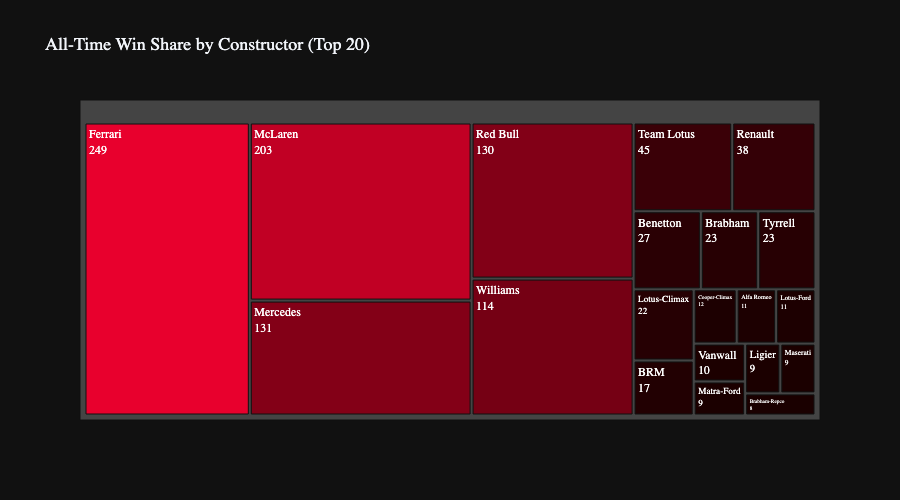

In [14]:
win_share = df_mapped[df_mapped['Year'] <= 2025].groupby('Constructor')['Win'].sum().reset_index()
win_share = win_share[win_share['Win'] > 0].sort_values('Win', ascending=False)

# Color mapping
win_share['Color'] = win_share['Constructor'].map(TOP_6_COLORS).fillna('#888888')

fig = px.treemap(
    win_share.head(20), path=['Constructor'], values='Win',
    title='All-Time Win Share by Constructor (Top 20)',
    color='Win',
    color_continuous_scale=['#1a0000', '#e8002d'],
    template='plotly_dark'
)
fig.update_layout(
    font=dict(family='DM Sans'), title_font_size=18, height=500,
    coloraxis_showscale=False
)
fig.update_traces(textinfo='label+value', textfont_size=12)
fig.show()

---

## GP-level view: zooming in from seasons to individual races

The earlier sections aggregated by year. This section drops one level of resolution and looks at the sport Grand Prix by Grand Prix. The data shift: we switch from `rq1_constructor_dominance.csv` (season totals) to the race-level table from `rq2_grid_finish_circuits.csv`, filter to winners only, and re-aggregate per Race Name. That gives us 1,153 historical race winners across 46 distinct GPs, spanning 1950-2026.

In [15]:
# Switch data source: race-level winners from the grid/finish dataset
gp_df = pd.read_csv('../final_datasets/rq2_grid_finish_circuits.csv')
winners = gp_df[gp_df['Finish Position'] == 1.0].copy()

print(f"Total race winners: {len(winners)}")
print(f"Unique GPs: {winners['Race Name'].nunique()}")
print(f"Year range: {int(winners['Year'].min())} - {int(winners['Year'].max())}")
print()
print("Top 10 GPs by total editions:")
print(winners['Race Name'].value_counts().head(10))

Total race winners: 1153
Unique GPs: 46
Year range: 1950 - 2026

Top 10 GPs by total editions:
Race Name
British GP          78
Italian GP          77
Monaco GP           71
Belgian GP          70
German GP           65
French GP           63
Spanish GP          55
Canadian GP         54
Brazilian GP        52
United States GP    46
Name: count, dtype: int64


## 14. Top constructor at each Grand Prix

For every GP with at least 10 editions on the calendar, who has won there most often. The answers are almost folk-knowledge at this point: Ferrari owns Monza, Mercedes owns Silverstone post-2014, McLaren owns Monaco across multiple eras. The chart confirms the folklore and also surfaces a few less-obvious patterns: Williams has more French GP wins than any other constructor, & Ferrari's Belgian GP tally is closer than you might expect.

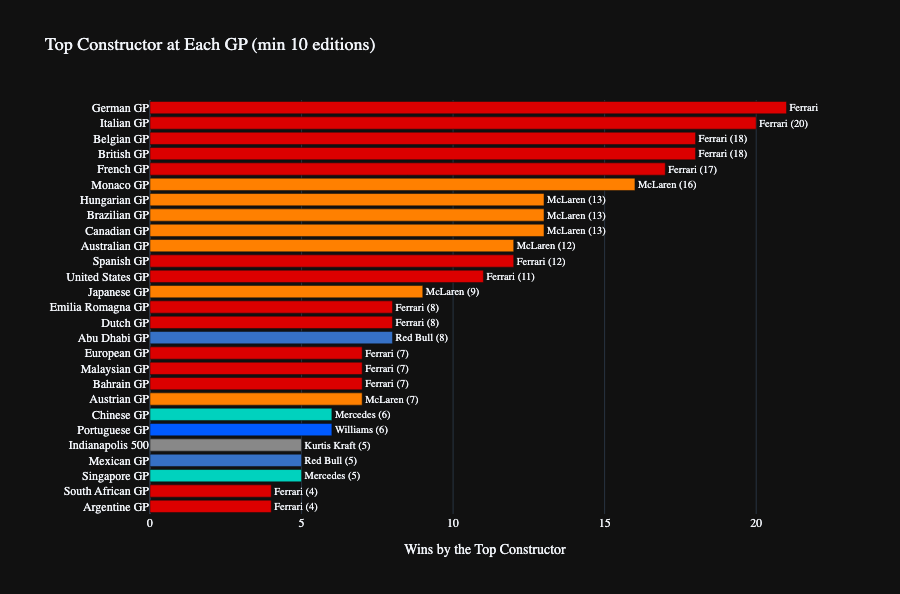

In [16]:
# For each GP with >=10 editions, find the constructor with the most wins
gp_counts = winners.groupby('Race Name').size().reset_index(name='editions')
established_gps = gp_counts[gp_counts['editions'] >= 10]['Race Name'].tolist()

gp_winner_stats = winners[winners['Race Name'].isin(established_gps)].groupby(
    ['Race Name', 'Constructor']
).size().reset_index(name='wins')

top_per_gp = gp_winner_stats.loc[
    gp_winner_stats.groupby('Race Name')['wins'].idxmax()
].sort_values('wins', ascending=True)

colors_gp = [TEAM_COLORS.get(c, '#888888') for c in top_per_gp['Constructor']]

fig = go.Figure(go.Bar(
    y=top_per_gp['Race Name'],
    x=top_per_gp['wins'],
    orientation='h',
    marker_color=colors_gp,
    text=top_per_gp['Constructor'] + ' (' + top_per_gp['wins'].astype(str) + ')',
    textposition='outside'
))
fig.update_layout(
    title='Top Constructor at Each GP (min 10 editions)',
    xaxis_title='Wins by the Top Constructor',
    yaxis_title='',
    template='plotly_dark',
    height=max(500, len(top_per_gp) * 22),
    font=dict(family='DM Sans'),
    title_font_size=18,
    margin=dict(l=150)
)
fig.show()

## 15. Most-dominated Grand Prix

Same data, framed differently. For each GP we compute win share = top constructor's wins / total winners. A high bar means one team has owned the race historically; a low bar means the winners' list is spread out. The circuits that cluster near the top are the ones fans already associate with specific teams: Monza for Ferrari, Silverstone for Williams/Mercedes, Hungaroring for McLaren's 90s run. The bottom of the chart is mostly modern street tracks with short histories where no one has had time to build a record.

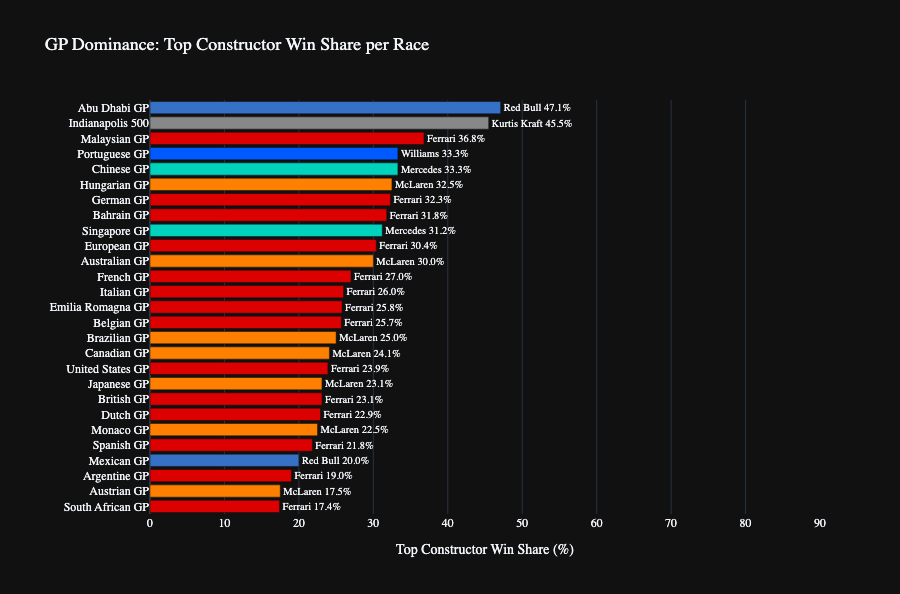

In [17]:
# Dominance per GP: top constructor's share of that race's wins
gp_dom_agg = gp_winner_stats.groupby('Race Name').agg(
    top_wins=('wins', 'max'),
    total_wins=('wins', 'sum')
).reset_index()

top_constructor_per_gp = gp_winner_stats.loc[
    gp_winner_stats.groupby('Race Name')['wins'].idxmax()
][['Race Name', 'Constructor']]

gp_dom_agg = gp_dom_agg.merge(top_constructor_per_gp, on='Race Name')
gp_dom_agg['dom_pct'] = (gp_dom_agg['top_wins'] / gp_dom_agg['total_wins'] * 100).round(1)
gp_dom_agg = gp_dom_agg.sort_values('dom_pct', ascending=True)

colors_dom = [TEAM_COLORS.get(c, '#888888') for c in gp_dom_agg['Constructor']]

fig = go.Figure(go.Bar(
    y=gp_dom_agg['Race Name'],
    x=gp_dom_agg['dom_pct'],
    orientation='h',
    marker_color=colors_dom,
    text=gp_dom_agg.apply(lambda r: f"{r['Constructor']} {r['dom_pct']}%", axis=1),
    textposition='outside'
))
fig.update_layout(
    title='GP Dominance: Top Constructor Win Share per Race',
    xaxis_title='Top Constructor Win Share (%)',
    yaxis_title='',
    xaxis=dict(range=[0, 90]),
    template='plotly_dark',
    height=max(500, len(gp_dom_agg) * 22),
    font=dict(family='DM Sans'),
    title_font_size=18,
    margin=dict(l=150)
)
fig.show()

---

## Chapter 1 narrative: dynasties interrupted by revolution

The stacked area and the Dominance Index together frame the same story from two angles. What the 75-season sweep shows:

1. **Dominance is never permanent.** Every era we mark on the chart ends with a regulation change. Rear-engine rules in 1961, turbo ban in 1989, active suspension ban in 1994, V10 freeze in 2006, V6 hybrid intro in 2014, ground-effect return in 2022. Empires fall on rule changes, not on slow decline.
2. **Ferrari is the only constant.** They are the only constructor with a continuous data band from 1950 to 2025. They are rarely the best team in any given era, but they are always there.
3. **Two peaks of near-total dominance.** 1988 McLaren won 15 of 16 races (93.8%) with Senna and Prost locked into the most intense intra-team rivalry in the sport's history. 2023 Red Bull won 21 of 22 (95.5%), effectively a single-driver season: Verstappen took 19 of those 21 personally. Same dominance rate, very different human story. The first was shared; the second was owned.
4. **Mercedes 2014-2021 is the longest recent dynasty.** Eight consecutive constructors' titles, Hamilton winning six of the eight drivers' titles. On the stacked area this shows up as a wide teal band that crowds every other color into a fraction of the frame.
5. **Scoring inflation makes points a trap for cross-era comparison.** A 2020s backmarker can out-score a 1970s champion on paper. Wins are the stable metric, which is why the Dominance Index uses them and the shipped UI defaults to the win-share lollipop when users switch tabs.

Design-wise, the chapter works because it pairs a chart that shows every season (stacked area) with a chart that emphasises extreme seasons (Dominance Index lollipop). One is the sweep of history; the other is the punctuation marks inside it.